# Notebook Description

Introduction

This notebook presents a secondary exploratory data analysis (EDA) conducted on a filtered subset of the Amazon Reviews dataset, focusing on the top 30 most reviewed products.

After analysing the full dataset, the team extracted this smaller subset to create a more manageable dataset for deeper analysis and experimentation. By concentrating on the most reviewed products, the dataset captures products with high customer engagement and a large volume of reviews, making them suitable for pattern analysis and modelling tasks.

The purpose of this notebook is to briefly explore the structure and patterns of the newly created subset dataset and ensure it is suitable for subsequent stages of the project.

The analysis in this notebook focuses on:
- Understanding the distribution of reviews across the selected products
- Examining review ratings and sentiment patterns
- Exploring text features and usage of words within reviews
- Identifying basic statistical patterns in the reduced dataset

This step ensures that the extracted dataset maintains meaningful patterns from the original large dataset and is appropriate for downstream analysis, modelling, and visualisation tasks.

In [1]:
# Install necessary libraries
!pip install spacy

!python -m spacy download en_core_web_sm

!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 26.3 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [30]:
#Load Neccessary Libraries

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from pathlib import Path
from wordcloud import WordCloud
from collections import Counter
import spacy
import fasttext
import os
import urllib.request

In [31]:
# Download the FastText language identification model

#Check if the model already exists
model_path = "lid.176.bin"
if not os.path.exists(model_path):
    #Download manually using wget
    print("Downloading FastText language ID model...")
    url = "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin"
    urllib.request.urlretrieve(url, model_path)
    print("Download complete")

#Load the  model
lang_model = fasttext.load_model(model_path)
print("FastText model loaded successfully!")

FastText model loaded successfully!


In [3]:
# Establish the file path to the Parquet file

FILE = "amazon_reviews_categories.csv"

# Create a DuckDB connection
con = duckdb.connect(database=":memory:")

In [4]:
def check_file(file_path=FILE):
    """
    check if the csv file exists and preview the data.
    Includes error handling for file access and SQL execution.
    """  
    con = None

    try:
        # check if file exists
        file_path = Path(file_path)
        if not file_path.is_file():
            raise FileNotFoundError(f"File not found: {file_path}")
        
        # connect to duckdb
        con = duckdb.connect(database=":memory:")
        
        # preview first few rows of the dataset
        preview = con.execute(f"""
            SELECT * 
            FROM '{file_path}'
            LIMIT 5
        """).fetchdf()
        return preview
    
    except FileNotFoundError as e:
        print(f"Error: {e}")
        
    except duckdb.Error as e:
        print(f"DuckDB Error: {e}")
        
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Call the function to check the file and preview the data
check_file("amazon_reviews_categories.csv")   
        

,asin,category,reviewerID,reviewerName,overall,summary,reviewText,unixReviewTime,reviewTime,verified,vote
0,B00CYQP3AK,Amazon Devices & Accessories,A3UXVNOFC8TJPT,Bkonasek,5.0,Great product,I received this as a birthday present. I am do...,1382140800,"10 19, 2013",False,2
1,B00CYQP3AK,Amazon Devices & Accessories,AC2VR9U3NN2UD,tikitoo,2.0,Battery Issues and Light bleed - 2nd time Not ...,Battery will not charge to 100%. When I receiv...,1382140800,"10 19, 2013",True,22
2,B00CYQP3AK,Amazon Devices & Accessories,A14D0LJ1YRLLCI,gabbie03,1.0,Missing promised features. Not ready for prime...,Buyer Beware. these units are being shipped ri...,1382140800,"10 19, 2013",True,54
3,B00CYQP3AK,Amazon Devices & Accessories,A3FVF1JIOA5GEK,MN_Ranger,5.0,Amazing Performance Worthy of Upgrade,"Netflix Issue:\nWhen I first got the KFHDX, I ...",1382054400,"10 18, 2013",True,577
4,B00CYQP3AK,Amazon Devices & Accessories,A3KP101J8H7EWY,L.D.K,5.0,This is by far the best tablet for the price,"I have owned many versions of the Kindle, and ...",1382054400,"10 18, 2013",True,8


In [5]:
# view the data schema
con.execute(f"DESCRIBE SELECT * FROM '{FILE}' LIMIT 0").fetchdf()

,column_name,column_type,null,key,default,extra
0,asin,VARCHAR,YES,None,None,None
1,category,VARCHAR,YES,None,None,None
2,reviewerID,VARCHAR,YES,None,None,None
3,reviewerName,VARCHAR,YES,None,None,None
4,overall,DOUBLE,YES,None,None,None
5,summary,VARCHAR,YES,None,None,None
6,reviewText,VARCHAR,YES,None,None,None
7,unixReviewTime,BIGINT,YES,None,None,None
8,reviewTime,VARCHAR,YES,None,None,None
9,verified,BOOLEAN,YES,None,None,None


In [6]:
con.execute(f"""
CREATE TABLE Reviews AS
SELECT *
FROM read_csv_auto('{FILE}')
""")

In [7]:
#Check the total number of rows in the dataset
row_count = con.execute(f"""
            SELECT COUNT(*) AS total_rows
            FROM reviews
            """).fetchdf()
row_count

,total_rows
0,829621


The dataset contains **829,621 rows**, meaning there are 829,621 thousand reviews in total. 
This is as a result of filtering out top thirty product and matching them to their respective categories.

## Duplicate check

In [8]:
duplicates_count = con.execute(f"""
SELECT COUNT(*) AS total_duplicates
FROM (
    SELECT *, COUNT(*) OVER(PARTITION BY asin, reviewerID) AS count
    FROM reviews
) sub
WHERE count > 1
""").fetchdf()

duplicates_count

,total_duplicates
0,131354


In [9]:
dinstinct_text = con.execute(f"""SELECT asin, reviewerID,category,
       COUNT(DISTINCT reviewText) AS distinct_texts,
       COUNT(*) AS total_rows
FROM reviews
GROUP BY asin, reviewerID, category
HAVING COUNT(*) > 1
ORDER BY total_rows Desc
LIMIT 50;
""").fetchdf()

dinstinct_text

,asin,reviewerID,category,distinct_texts,total_rows
0,B000W5QSYA,A5Z6TIROUVA5O,Pet Supplies,2,30
1,B000W5QSYA,A1JBCVZCVEIQZN,Pet Supplies,2,12
2,B000W5QSYA,A2OY938ZNE1GTB,Pet Supplies,6,12
3,B000W5QSYA,A1AG2S30FR8M8B,Pet Supplies,6,12
4,B000W5QSYA,A1FCIAE7P5EB7Q,Pet Supplies,5,10
5,B000W5QSYA,A1TGJFDYBPO1AY,Pet Supplies,4,10
6,B000W5QSYA,AMOD4K1SGQBOB,Pet Supplies,4,10
7,B000W5QSYA,A26Y0XX6GSR500,Pet Supplies,1,10
8,B000W5QSYA,A2AOZQIF9587WP,Pet Supplies,4,10
9,B000W5QSYA,A1NRI0RFZAYLYK,Pet Supplies,1,10


The total_rows column represents the number of review records associated with a reviewer–product combination in the dataset. 

The distinct_texts column indicates the number of unique review texts among those rows. 

When total_rows is greater than distinct_texts, it suggests that some reviews have been duplicated in the dataset. 

These duplicates are likely issues of the data collection process rather than repeated reviewer behavior.

In [10]:
# Sample reviews for a specific product  and reviewer with one distinct review text

review_sample1 = con.execute(f"""
SELECT *
FROM reviews
WHERE asin = 'B000W5QSYA'
  AND reviewerID = 'A1NRI0RFZAYLYK'
ORDER BY reviewTime
LIMIT 10;
""").fetchdf()

review_sample1

,asin,category,reviewerID,reviewerName,overall,summary,reviewText,unixReviewTime,reviewTime,verified,vote
0,B000W5QSYA,Pet Supplies,A1NRI0RFZAYLYK,KimberlyM,1.0,Huge Chunks of Mold!!,We just found a HUGE hunk of mold (like bigger...,1444348800,"10 9, 2015",False,22
1,B000W5QSYA,Pet Supplies,A1NRI0RFZAYLYK,KimberlyM,1.0,Huge Chunks of Mold!!!,We just found a HUGE hunk of mold (like bigger...,1444348800,"10 9, 2015",False,4
2,B000W5QSYA,Pet Supplies,A1NRI0RFZAYLYK,KimberlyM,1.0,Huge Mold in Bag!!!,We just found a HUGE hunk of mold (like bigger...,1444348800,"10 9, 2015",False,None
3,B000W5QSYA,Pet Supplies,A1NRI0RFZAYLYK,KimberlyM,1.0,Toxic Mold in Bag!!!,We just found a HUGE hunk of mold (like bigger...,1444348800,"10 9, 2015",False,5
4,B000W5QSYA,Pet Supplies,A1NRI0RFZAYLYK,KimberlyM,1.0,Toxic Mold in Bag!,We just found a HUGE hunk of mold (like bigger...,1444348800,"10 9, 2015",False,185
5,B000W5QSYA,Pet Supplies,A1NRI0RFZAYLYK,KimberlyM,1.0,Huge Chunks of Mold!!,We just found a HUGE hunk of mold (like bigger...,1444348800,"10 9, 2015",False,22
6,B000W5QSYA,Pet Supplies,A1NRI0RFZAYLYK,KimberlyM,1.0,Huge Chunks of Mold!!!,We just found a HUGE hunk of mold (like bigger...,1444348800,"10 9, 2015",False,4
7,B000W5QSYA,Pet Supplies,A1NRI0RFZAYLYK,KimberlyM,1.0,Huge Mold in Bag!!!,We just found a HUGE hunk of mold (like bigger...,1444348800,"10 9, 2015",False,None
8,B000W5QSYA,Pet Supplies,A1NRI0RFZAYLYK,KimberlyM,1.0,Toxic Mold in Bag!!!,We just found a HUGE hunk of mold (like bigger...,1444348800,"10 9, 2015",False,5
9,B000W5QSYA,Pet Supplies,A1NRI0RFZAYLYK,KimberlyM,1.0,Toxic Mold in Bag!,We just found a HUGE hunk of mold (like bigger...,1444348800,"10 9, 2015",False,185


In [11]:
review_sample2 = con.execute(f"""
SELECT *
FROM reviews
WHERE asin = 'B000W5QSYA'
  AND reviewerID = 'A2OY938ZNE1GTB'
ORDER BY reviewTime
LIMIT 13;
""").fetchdf()

review_sample2

,asin,category,reviewerID,reviewerName,overall,summary,reviewText,unixReviewTime,reviewTime,verified,vote
0,B000W5QSYA,Pet Supplies,A2OY938ZNE1GTB,susan,5.0,fussy dog,as my dog has gotten older she has also gotten...,1366675200,"04 23, 2013",True,None
1,B000W5QSYA,Pet Supplies,A2OY938ZNE1GTB,susan,5.0,fussy dog,as my dog has gotten older she has also gotten...,1366675200,"04 23, 2013",True,None
2,B000W5QSYA,Pet Supplies,A2OY938ZNE1GTB,susan,5.0,Five Stars,always buy this kink of dog food and my dog se...,1434758400,"06 20, 2015",True,None
3,B000W5QSYA,Pet Supplies,A2OY938ZNE1GTB,susan,5.0,... taste of the wild and my dog seems to like...,always buy taste of the wild and my dog seems ...,1434758400,"06 20, 2015",True,None
4,B000W5QSYA,Pet Supplies,A2OY938ZNE1GTB,susan,5.0,Five Stars,always buy this kink of dog food and my dog se...,1434758400,"06 20, 2015",True,None
5,B000W5QSYA,Pet Supplies,A2OY938ZNE1GTB,susan,5.0,... taste of the wild and my dog seems to like...,always buy taste of the wild and my dog seems ...,1434758400,"06 20, 2015",True,None
6,B000W5QSYA,Pet Supplies,A2OY938ZNE1GTB,susan,5.0,puppy loves this,this is a great product for a dog prone to all...,1376265600,"08 12, 2013",True,5
7,B000W5QSYA,Pet Supplies,A2OY938ZNE1GTB,susan,5.0,puppy loves this,this is a great product for a dog prone to all...,1376265600,"08 12, 2013",True,5
8,B000W5QSYA,Pet Supplies,A2OY938ZNE1GTB,susan,5.0,great,have been buying this brand of dog food for a ...,1375574400,"08 4, 2013",True,None
9,B000W5QSYA,Pet Supplies,A2OY938ZNE1GTB,susan,5.0,good product,my dog is getting on in years and i wanted a p...,1375574400,"08 4, 2013",True,None


In [12]:

review_sample3 = con.execute(f"""
SELECT *
FROM reviews
WHERE asin = 'B000X1MX7E'
  AND reviewerID = 'A3QQ0HPXT33ZRJ'
ORDER BY reviewTime
LIMIT 10;
""").fetchdf()

review_sample3



,asin,category,reviewerID,reviewerName,overall,summary,reviewText,unixReviewTime,reviewTime,verified,vote
0,B000X1MX7E,Audible Books & Originals,A3QQ0HPXT33ZRJ,john w evans jr,3.0,Three Stars,Follett is a good story teller but he lets his...,1415404800,"11 8, 2014",True,None
1,B000X1MX7E,Audible Books & Originals,A3QQ0HPXT33ZRJ,john w evans jr,3.0,Three Stars,Follett is a good story teller but he lets his...,1415404800,"11 8, 2014",True,None


After analysing the sample reviews, several instances of duplicated reviews were observed
for the same reviewer and product combination. These duplicates often contained
identical review text but slightly different summaries or vote counts.

This pattern likely results from the data collection process, where reviews were
captured multiple times as vote counts changed or when users edited their reviews.
To avoid bias in the analysis, duplicated reviews were identified using the
combination of asin, reviewerID, and reviewText and treated accordingly.

## Missing Values Analysis

In [13]:
#check total number of missing values
missing_values = con.execute(f"""
SELECT
    SUM(CASE WHEN asin IS NULL THEN 1 ELSE 0 END) AS missing_asin,
    SUM(CASE WHEN category IS NULL THEN 1 ELSE 0 END) AS missing_category,                         
    SUM(CASE WHEN reviewerID IS NULL THEN 1 ELSE 0 END) AS missing_reviewerID,
    SUM(CASE WHEN reviewerName IS NULL THEN 1 ELSE 0 END) AS missing_reviewerName,
    SUM(CASE WHEN overall IS NULL THEN 1 ELSE 0 END) AS missing_overall,
    SUM(CASE WHEN reviewText IS NULL THEN 1 ELSE 0 END) AS missing_reviewText,
    SUM(CASE WHEN vote IS NULL THEN 1 ELSE 0 END) AS missing_vote,
    SUM(CASE WHEN verified IS NULL THEN 1 ELSE 0 END) AS missing_verified,
    SUM(CASE WHEN reviewTime IS NULL THEN 1 ELSE 0 END) AS missing_reviewTime,
    SUM(CASE WHEN unixReviewTime IS NULL THEN 1 ELSE 0 END) AS missing_unixReviewTime
                                                          
FROM reviews
""").fetchdf()

missing_values

,missing_asin,missing_category,missing_reviewerID,missing_reviewerName,missing_overall,missing_reviewText,missing_vote,missing_verified,missing_reviewTime,missing_unixReviewTime
0,0.0,0.0,0.0,32.0,0.0,471.0,792455.0,0.0,0.0,0.0


## Missing Values Analysis

We performed a missing values check across all columns of the dataset, which contains **233,055,327 reviews**. Here is the detailed interpretation:

- **asin (Product ID)** : Zero missing values.  
  Every review has a valid product ID, which is essential for linking reviews to products. 

- **reviewerID (Reviewer ID)** :Zero missing values.  
  Each review has a unique reviewer ID, allowing us to track reviewer activity. 

- **reviewerName** : 32 missing values.  
  A very small portion of reviews do not have a reviewer name. Since this is negligible, we may decide to leave them as is or drop/replace with unknown and flag for downstream tasks.  

- **overall(Rating)**: Zero missing values.  
  All reviews have a rating score, which is critical for sentiment analysis. 

- **reviewText** :471 missing values.  
  A small fraction of reviews have no text. Depending on the task, these rows could be dropped (for text-based sentiment analysis) or flagged.  

- **vote** :792,455 missing values.  
  Most reviews have no vote. This is expected because not all reviews receive user votes. For analysis, we can impute missing votes as `0` instead of dropping them.  

- **verified (Verified Purchase)** : Zero missing values.  
  Every review has a verified purchase status, allowing filtering for genuine purchases. 

- **reviewTime and unixReviewTime** :Zero missing values.  
  All reviews have timestamps, which are necessary for time-based analysis or modeling. 

**Key Takeaways:**  
1. Critical columns (asin, reviewerID, overall, verified, reviewTime) are complete.  
2. Minor missing data (reviewerName, reviewText) can be handled depending on the analysis.  
3. The vote column has many missing values, but imputing with 0 ensures no data loss and maintains reproducibility.

## Verified purchase Analysis

In [14]:
# Analsye the number of verified purchases and non verified purchases
verified_purchases = con.execute(f"""
SELECT
    verified,
    COUNT(*) AS review_count
FROM reviews
GROUP BY verified
""").fetchdf()

verified_purchases

,verified,review_count
0,False,152321
1,True,677300


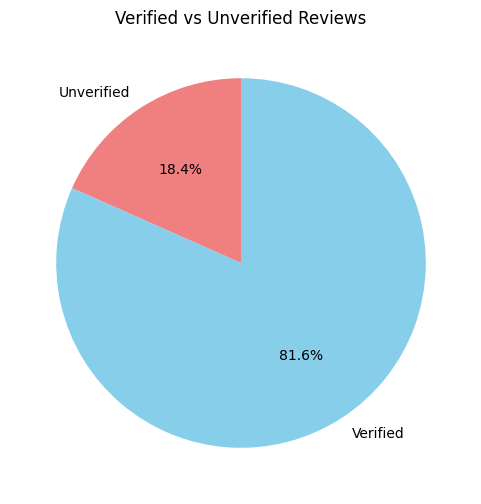

In [15]:
#visaulise the verified purchase distribution

verified_purchase_counts= [152321, 677300]
labels = ['Unverified', 'Verified']

plt.figure(figsize=(6,6))
plt.pie(verified_purchase_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'skyblue'])
plt.title("Verified vs Unverified Reviews")
plt.show()

Majority of the reviews are verified:
- 677,300 reviews are from verified purchases.
- This is good indication as verified reviews are generally more reliable.

Unverified reviews:
- 152,321 reviews are unverified.
- These reviews might be flagged during the suspicious reviews ML analysis.

#

In [16]:
#average ratings for verified vs unverified purchases
average_verification_ratings = con.execute(f"""SELECT verified, AVG(overall) AS avg_rating
FROM reviews
GROUP BY verified;
""").fetchdf()

average_verification_ratings

,verified,avg_rating
0,False,4.404278
1,True,4.453408


The average rating for verified purchases is (4.45) is slightly higher than for unverified reviews (4.40). 

This suggests that verified customers tend to provide more positive feedback. 

However, the difference is marginal, indicating that unverified reviews do not drastically deviate from verified ones at an aggregate level

## Summary statistics of the Numeric Columns

In [17]:
ratings_summary = con.execute(f"""
        SELECT 
            AVG(overall) AS avg_overall,
            MIN(overall) AS min_overall,
            MAX(overall) AS max_overall
        FROM reviews
    """).fetchdf()
ratings_summary

,avg_overall,min_overall,max_overall
0,4.444387,1.0,5.0


avg_overall = 4.444387
   - On average, reviewers gave the products about 4.23 stars.
   
min_overall = 1.0
   - The lowest rating in the dataset is 1 star.

max_overall = 5.0
   - The highest rating is 5 stars.

In [18]:
# Summary statistics of the Votes

votes_summary = con.execute(f"""
        SELECT
            COUNT(TRY_CAST(vote AS BIGINT)) AS numeric_votes,
            AVG(TRY_CAST(vote AS BIGINT))   AS avg_vote,
            MIN(TRY_CAST(vote AS BIGINT))   AS min_vote,
            MAX(TRY_CAST(vote AS BIGINT))   AS max_vote
        FROM reviews
    """).fetchdf()
votes_summary

,numeric_votes,avg_vote,min_vote,max_vote
0,37109,9.756016,2,999



numeric_votes = 37,109
 - Out of all reviews, 37,109 votes were valid numbers. The rest were probably missing, empty, or non-numeric.

avg_vote = 9.75
 - On average, each review that had a numeric vote received about 9–10 helpful votes.

min_vote = 2
 - The smallest number of votes a review got was 2.

max_vote = 999
- The highest number of votes a review received was 999.

From the data schema:
- vote is stored as a VARCHAR.
- This means the column contains text, not numbers.   
   - So some entries might be like "5", "12", or even "N/A", "unknown", or empty strings.

- TRY_CAST(vote AS BIGINT)tries to turn the text into a number:
	-	"5" = 5 
	-	"12" = 12 
	-	"N/A" = NULL (ignored in calculations, so it doesn’t crash the query)

- Without TRY_CAST, DuckDB would fail when it sees non-numeric text. With it, only the clean numeric votes are counted in COUNT, AVG, MIN, and MAX

## Categorical Column analysis

In [19]:
# Query to count total number of unique reviewers

reviewer_count = con.execute(f"""
SELECT COUNT(DISTINCT reviewerID) AS total_reviewers
FROM reviews
""").fetchdf()
reviewer_count

,total_reviewers
0,631943


The dfiltered dataset 631,943 unique reviewers.

 - Every reviewer is counted only once, even if they wrote multiple reviews.
 
- So while the dataset might have more total reviews, these come from about 631,943 different people.

- This indicates a very diverse set of users, not dominated by just a few reviewers.

### Reviews Distribution by Product Category

In [20]:
category_df = con.execute(f"""
SELECT
    category,                      
    COUNT(*) AS total_reviews
FROM reviews
GROUP BY category
ORDER BY total_reviews DESC
LIMIT 10
""").fetchdf()

category_df

,category,total_reviews
0,Books,468256
1,Movies & TV,114535
2,Audible Books & Originals,75607
3,Electronics,49412
4,Pet Supplies,46210
5,Amazon Devices & Accessories,28304
6,Home & Kitchen,27595
7,"Clothing, Shoes & Jewelry",19702


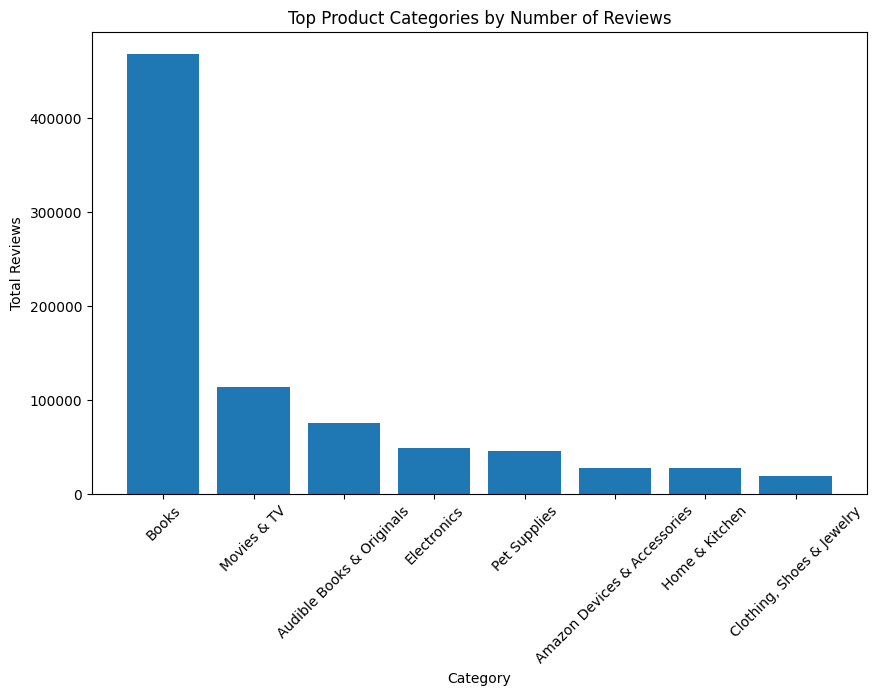

In [21]:
plt.figure(figsize=(10,6))
plt.bar(category_df["category"], category_df["total_reviews"])
plt.xticks(rotation=45)
plt.title("Top Product Categories by Number of Reviews")
plt.xlabel("Category")
plt.ylabel("Total Reviews")
plt.show()

The distribution of reviews across product categories shows that Books account for the largest share of reviews in the dataset. This is expected given the high volume of book publications and reviews on Amazon. Categories such as Movies & TV and Audible Books & Originals also show significant review activity, reflecting their popularity among consumers.

### Average Rating by Category

In [22]:
con.execute(f"""
SELECT
    category,        
    ROUND(AVG(overall), 2) AS avg_rating,
    COUNT(*) AS total_reviews
FROM reviews
GROUP BY category
ORDER BY avg_rating DESC
""").fetchdf()

,category,avg_rating,total_reviews
0,Movies & TV,4.76,114535
1,Home & Kitchen,4.59,27595
2,Pet Supplies,4.51,46210
3,Audible Books & Originals,4.43,75607
4,Books,4.40,468256
5,Amazon Devices & Accessories,4.30,28304
6,Electronics,4.22,49412
7,"Clothing, Shoes & Jewelry",4.20,19702


The average rating varies across product categories. Categories such as movies $ tv and home and kitchen tend to exhibit higher average ratings compared to others. This may reflect higher customer satisfaction or stronger brand loyalty within these product categories

### Verified vs Unverified Reviews by Category

In [23]:
con.execute(f"""
SELECT
    category,          
    verified,
    COUNT(*) AS review_count
FROM reviews
GROUP BY category, verified
ORDER BY category Desc
""").fetchdf()

,category,verified,review_count
0,Pet Supplies,True,42953
1,Pet Supplies,False,3257
2,Movies & TV,False,24986
3,Movies & TV,True,89549
4,Home & Kitchen,True,22708
5,Home & Kitchen,False,4887
6,Electronics,True,46970
7,Electronics,False,2442
8,"Clothing, Shoes & Jewelry",False,1570
9,"Clothing, Shoes & Jewelry",True,18132


The comparison between verified and unverified reviews across categories provides insights into potential suspicious review activity. Categories with a higher proportion of unverified reviews may warrant further investigation, as unverified purchases are more likely to be associated with incentivized or fraudulent reviews.

In [24]:
# check the length of the review text in characters
review_length = con.execute(f"""
        SELECT 
            AVG(LENGTH(reviewText)) AS avg_len,
            MIN(LENGTH(reviewText)) AS min_len,
            MAX(LENGTH(reviewText)) AS max_len
        FROM reviews
    """).fetchdf()

review_length

,avg_len,min_len,max_len
0,226.20694,1,31090


These numbers describe the length of the review text in characters:

avg_len = 226.20694 

 - On average, each review has about 226 characters.

min_len = 1

- The shortest review is 1 character long.

max_len = 31,090
- The longest review is 31,090 characters, which is extremely long, probably a very detailed review or someone pasting a lot of text.

In [25]:
# check the average number of words in the review text

avg_word_count = con.execute(f"""
        SELECT 
            AVG(array_length(string_split(reviewText, ' '))) AS avg_words
        FROM reviews
        WHERE reviewText IS NOT NULL
    """).fetchdf()

avg_word_count

,avg_words
0,42.011409


Average words per review is approximately 42 words

- Most reviews are short to medium in length, roughly the size of a short paragraph.

- Very short reviews (1–10 words) may provide limited information and could be considered low quality.

- Extremely long reviews (e.g., >1,000 words) are outliers and may skew averages.


Knowing the average word count helps:

- Detect and potentially filter out low quality or extremely long reviews.

- Decide on preprocessing steps for NLP tasks (e.g., tokenization).

- Understand user engagement and the richness of review content.

In [26]:
# Detect unusual patterns in the review text.
review_stats = con.execute(f"""
    SELECT 
        SUM(CASE WHEN reviewText IS NULL OR LENGTH(TRIM(reviewText))=0 THEN 1 ELSE 0 END) AS empty_reviews,
        SUM(CASE WHEN reviewText IS NOT NULL AND LENGTH(TRIM(reviewText)) BETWEEN 1 AND 10 THEN 1 ELSE 0 END) AS very_short_reviews,
        SUM(CASE WHEN LENGTH(TRIM(reviewText)) > 1000 THEN 1 ELSE 0 END) AS very_long_reviews
    FROM reviews
""").fetchdf()

review_stats

,empty_reviews,very_short_reviews,very_long_reviews
0,474.0,39169.0,26661.0


empty_reviews = 474.0
- About 474 reviews have no text at all. These are basically empty entries.

very_short_reviews = 39,169
- 39,169 reviews are extremely short (1–10 characters). These likely don’t give much useful information.

very_long_reviews = 26,661.0
- 26,661 reviews are very long (>1,000 characters). These are detailed, possibly multi-paragraph reviews.

### Check for multiple language content, emojis, or special symbols.

In [27]:
# Count how many reviewerIDs have non-ASCII characters
non_ascii_reviewers = con.execute(f"""
SELECT COUNT (*) AS count_non_ascii_reviewers
FROM reviews
WHERE REGEXP_MATCHES(reviewerID, '[^\\x00-\\x7F]')
""").fetchdf()

non_ascii_reviewers


,count_non_ascii_reviewers
0,0


In [28]:
# Count how many reviewText rows have non-ASCII characters
non_ascii_reviews = con.execute(f"""
SELECT COUNT (*) AS count_non_ascii_reviews
FROM reviews
WHERE REGEXP_MATCHES(reviewText, '[^\\x00-\\x7F]')
""").fetchdf()

non_ascii_reviews

,count_non_ascii_reviews
0,0


non_ascii_reviewers = 0

non_ascii_reviews = 0 
- means there are  no reviewsand reviewers with non-ASCII characters in the dataset.
- Everything in reviewText is plain ASCII standard English letters, numbers, and punctuation.

How does this infrom the project?
- No emojis, accented letters, or foreign-language characters are present.
- There is no need for special preprocessing for multi-language or emoji handling.
- The text analysis 
 pipeline can safely assume all text is English and ASCII.

In [32]:

#check for multiple langugages in the review text using FastText language identification model
chunk_size = 100000
offset = 0
found_non_english = False

while True:
    query = f"""
    SELECT reviewText
    FROM reviews
    LIMIT {chunk_size} OFFSET {offset}
    """
    
    chunk = con.execute(query).fetchdf()
    
    if chunk.empty:
        break

    for text in chunk['reviewText']:
        if not text:
            continue

        try:
            lang = lang_model.predict(str(text))[0][0]
        except ValueError:
            continue

        if lang != "__label__en":
            print(f"Non-English review detected at offset {offset}")
            found_non_english = True
            break

    if found_non_english:
        break

    offset += chunk_size

if not found_non_english:
    print("All reviews are in English.")

All reviews are in English.


In [33]:
# Check for URLs and HTML tags in the review text, which can indicate spam or low-quality content.
df_text_quality = con.execute(f"""
SELECT
    COUNT(*) AS total_reviews,
    SUM(CASE WHEN regexp_matches(reviewText, 'http[s]?://|www\\.') THEN 1 ELSE 0 END) AS url_reviews,
    SUM(CASE WHEN regexp_matches(reviewText, '<[^>]+>') THEN 1 ELSE 0 END) AS html_reviews

FROM reviews
WHERE reviewText IS NOT NULL
""").fetchdf()

df_text_quality

,total_reviews,url_reviews,html_reviews
0,829150,603.0,1087.0




- Total reviews: 829,150 
- Reviews containing URLs: 603.0 
- Reviews containing HTML tags: 1087.0

**Implications:**  
- Only a small fraction of reviews include URLs or HTML.  
- Reviews with URLs/HTML could indicate promotional or copied content, but presence alone does not confirm a review is fake.  
- For suspicious review detection, these features are useful signals when combined with other indicators like review length or reviewer activity.

In [34]:
#view some of these reviews that contain URLs or HTML tags to understand the nature of these reviews.

# Make pandas show full text
pd.set_option("display.max_colwidth", None)

# Query DuckDB for first 10 reviews with URLs or HTML
url_html_reviews = con.execute(f"""
SELECT reviewText
FROM reviews
WHERE reviewText IS NOT NULL
  AND (regexp_matches(reviewText, 'http[s]?://|www\\.') 
       OR regexp_matches(reviewText, '<[^>]+>'))
LIMIT 5
""").fetchdf()


url_html_reviews

reviewText
0  To sum up what I will tell you about in the details below, for $229 you are getting a good deal on a tablet computer - especially if you compare it to the $199 for last year's first-generation Fire HD and the $500 or more you can spend on a Wi-Fi version of the iPad. Overall, if you consider the price and the functionality I think this is a great tool / toy if you watch a lot of video or play a lot of games on your device: the video quality is outstanding and you can really tell a difference between this and the new HD Fire.  If you are a first-time tablet buyer, where price vs. value is a key consideration, or if you are looking for an affordable tablet for the kids, I'd recommend the "regular" Kindle Fire HD that is only $139.  If you're comparing last year's HD model to this version and it is operating fine, I'd say save your money and continue to get your money's worth out of that one.\n\nMy review below compares a lot of the features of this version of the Fire HDX to the original Fire HD as well as this year's model of the Fire HD, but also some of the features for a first-time user.\n\nConsistent with my experience with setup of this year's model of the Kindle Fire HD, setup took a long time: despite being a brand new product, the Fire HDX attempted to download and install several operating software updates.  Software updates on a Kindle are usually in the background, and it was annoying watching the crashes and manual reboots.  Consistent with the Fire HD, it crashed during setup, playing a song, watching a TV show, and reading a book.  It took a little over an hour to get this thing up and running without consistent crashes but after the final software update it has worked as expected without further issues.\n\nScreen Display / Video Playback:\n\nThis version of the Fire has the absolute best screen display of any Fire model to date. Looking at the technical specs Amazon made some major changes in the display / resolution, and the picture appears more crisp: I compared the viewing experience watching with my standard test of the Fire devices over the past couple of years - don't laugh - the first episode of the Wonder Woman TV series from the 70's. The display on this Fire was one heck of a lot better in terms of sharpness than last year's model as well as this year's model of the Fire HD. For you technical folks out there, the display is 1,920 x 1,200 with 50% more pixels per inch than the Fire HD.\n\nWi-Fi Connectivity:\n\nThe initial Wi-Fi setup took some time as it wouldn't remember the password for my router after each software update / crash / reboot series.  After the final operating software update I mentioned above, however, it was fairly easy to connect to the Internet via Wi-Fi.\n\nMy standard test for trying out new gadgets is to see how fast they run side-by-side with a known piece of equipment doing the same test at the best place of Wi-Fi in my house and the worst place where it drags. In this comparison, I had this HDX version of the Fire sitting next to last year's and this year's version of the HD Fire, as well as last year's 8.9" HD Fire, Motorola RAZR smartphone, my iPad 2 (yes, the Kindle guy uses an iPad for work), and the first-generation 7" Fire (the model from two years ago) all just using a Wi-Fi connection vs. cellular connectivity.\n\nMy "normal" website test is to hit the mobile websites of FoxNews, CNN, my personalized Yahoo page, Google, and the Houston Chronicle. The ones that were usually slow on the other devices were faster on the HDX (Houston Chronicle and CNN), and for the other sites I couldn't tell a difference in speed at the location closest to my router. When I went to the slowest / worst reception location of my house, the speed did have a noticeable difference in the other devices as this one was a little bit faster than all but last year's model of the 7" Kindle Fire HD; yes, it was also faster than this year's model of the Fire HD but I attribute the increase

In order to view the full review text
The idea to use "pd.set_option("display.max_colwidth", None") was gotten from https://pandas.pydata.org/docs/user_guide/options.html#frequently-used-options

In [35]:
unique_product = con.execute(f"""SELECT COUNT(DISTINCT asin) AS unique_products
FROM reviews;
""").fetchdf()

unique_product

,unique_products
0,30


The dataset contains 30 unique products, identified by their asin (Amazon Standard Identification Number). 

This product depicts the top 30 most reviwed product from the original dataset that had 15,million unique product.

In [36]:
average_ratings = con.execute(f"""SELECT AVG(overall) AS average_rating
FROM reviews;
""").fetchdf()

average_ratings

,average_rating
0,4.444387


average ratings = 4.44

- This is skewed positively, meaning most reviews are on the higher end (4–5 stars).

In [37]:
ratings_distribution = con.execute(f"""SELECT overall AS rating, COUNT(*) AS count
FROM reviews
GROUP BY overall
ORDER BY rating;
""").fetchdf()

ratings_distribution

,rating,count
0,1.0,33192
1,2.0,28313
2,3.0,55569
3,4.0,132103
4,5.0,580444


In [38]:
ratings_skewness = con.execute(f"""SELECT skewness(overall) AS rating_skewness
FROM reviews;
""").fetchdf()

ratings_skewness


,rating_skewness
0,-2.02611


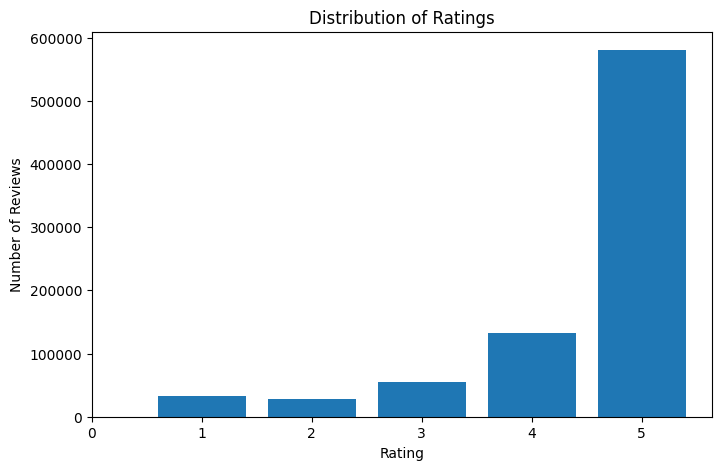

In [39]:
#plot the skewness of the ratings distribution using a bar chart

plt.figure(figsize=(8,5))
plt.bar(ratings_distribution['rating'], ratings_distribution['count'])
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks([0,1,2,3,4,5])
plt.show()

rating_skewness = -2.02611

- Negative skew confirms that ratings cluster toward the high end, with a long tail on the lower side.
	
- Insight: Most products get good reviews, a few low ratings exist, which confirms a strong positive bias in the dataset, which is common in large scale e-commerce review platforms.

### Temporal Analysis

In [40]:
# Check review per year
yearly_review = con.execute(f"""SELECT
    YEAR(TO_TIMESTAMP(unixReviewTime)) AS review_year,
    COUNT(*) AS reviews_count
FROM reviews
GROUP BY review_year
ORDER BY review_year;
""").fetchdf()

yearly_review

,review_year,reviews_count
0,1997,25
1,1998,102
2,1999,654
3,2000,1390
4,2001,1184
5,2002,1345
6,2003,915
7,2004,633
8,2005,1044
9,2006,766


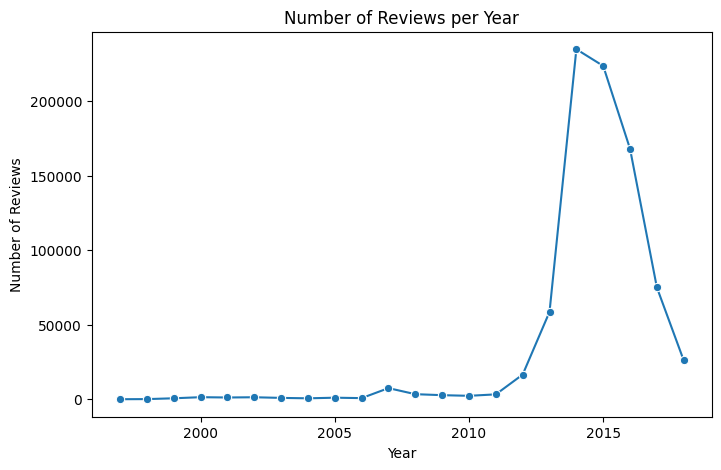

In [41]:

plt.figure(figsize=(8,5))
sns.lineplot(x='review_year', y='reviews_count', data= yearly_review, marker='o')
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')

#disable scientific notation
plt.ticklabel_format(style='plain', axis='y')
plt.show()

The temporal analysis reveals a gradual increase in review activity from the late 1990s, followed by increased growth between 2007 and 2012.

A sharp increase occurs between 2013 and 2014, reflecting the large scale adoption of e-commerce and increased reliance on online reviews.

The decline observed in the final year likely reflects data collection ending mid year rather than a genuine reduction in platform activity.

## Code References and Inspiration

Some code patterns used in this notebook were inspired by official documentation and publicly available learning resources. These include examples of data exploration, data manipulation, and visualization using Python data science libraries.

References include:
- Matplotlib Documentation: https://matplotlib.org/stable/index.html

- Seaborn Documentation: https://seaborn.pydata.org/

- DuckDB Documentation: https://duckdb.org/docs/

These resources were used as guidance when implementing data exploration and visualization steps.

### AI Assistance

ChatGPT 5.0 was used occasionally to assist with debugging and clarifying Python and SQL syntax. All analysis, implementation, and interpretation were completed by the team members.